<a href="https://colab.research.google.com/github/astgregory/Task_22-PricePredictionsForJapaneseCars/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%8F%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9622.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**В домашней работе необходимо выполнить следующее задание:**

1. Используя предложенный [датасет](https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv) японских машин, обучите модель предсказывать цены на японские автомобили.
2. Создайте обучающую, тестовую и проверочную выборки.
3. Оцените качество работы созданной сети, определите средний процент ошибки на проверочной выборке.
4. В качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
5. Выполнив задание, получите 3 балла.
6. Хотите 4 балла? Добейтесь ошибки менее 10%.
7. Хотите 5 баллов? Добейтесь ошибки менее 5%.


**Примечание**. Подробную информацию о датасете можно узнать на портале соревновани [kaggle.com](https://www.kaggle.com/datasets/doaaalsenani/used-cars-dataets/data).



In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv

--2025-11-19 07:54:33--  https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136735 (134K) [text/csv]
Saving to: ‘japan_cars_dataset.csv.1’

japan_cars_dataset. 100%[===================>] 133.53K   355KB/s    in 0.4s    

2025-11-19 07:54:34 (355 KB/s) - ‘japan_cars_dataset.csv.1’ saved [136735/136735]



In [ ]:
import pandas as pd
cars = pd.read_csv('japan_cars_dataset.csv', sep=',')

# Удалим строки с пустыми значениями
cars = cars.dropna()

# Выводим первые 10 машин
cars.head(10)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline
5,5,190,daihatsu,mira,2004,81400,660,at,2wd,rhd,gasoline
6,8,220,nissan,march,2010,117000,1200,at,2wd,rhd,gasoline
7,9,230,volkswagen,passat,2008,127763,3190,at,4wd,rhd,gasoline
8,10,275,mazda,bongo van,2010,178218,1800,mt,2wd,rhd,gasoline
9,11,283,honda,step wgn,2005,121655,2000,at,2wd,rhd,gasoline


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt


%matplotlib inline

In [ ]:
cars = cars.drop(columns=['Unnamed: 0', 'hand_drive'])

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            2318 non-null   int64 
 1   mark             2318 non-null   object
 2   model            2318 non-null   object
 3   year             2318 non-null   int64 
 4   mileage          2318 non-null   int64 
 5   engine_capacity  2318 non-null   int64 
 6   transmission     2318 non-null   object
 7   drive            2318 non-null   object
 8   fuel             2318 non-null   object
dtypes: int64(4), object(5)
memory usage: 163.1+ KB


**Нормализация стоимости**

In [ ]:
scaler = MinMaxScaler()
cars['price_normalized'] = scaler.fit_transform(cars[['price']])

**Кодирование строк**

In [ ]:
le = LabelEncoder()
for column in ['mark', 'model', 'transmission', 'drive', 'fuel']:
    cars[column] = le.fit_transform(cars[column])

**Разделение выборок**

In [ ]:
X = cars.drop(columns=['price_normalized'])
y = cars['price_normalized']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

In [ ]:
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

**Создание модели**

In [ ]:
model = Sequential()
model.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(200, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1))

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_mae', save_best_only=True, mode='min')

Обучение модели

In [ ]:
history= model.fit(X_train, y_train_scaled, epochs=200, validation_data=(X_val, y_val_scaled), callbacks=[checkpoint])

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.9863 - mae: 1.3070 - val_loss: 0.0924 - val_mae: 0.2449
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7231 - mae: 1.0018 - val_loss: 0.0698 - val_mae: 0.2122
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2095 - mae: 0.8296 - val_loss: 0.0545 - val_mae: 0.1754
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9914 - mae: 0.7663 - val_loss: 0.0777 - val_mae: 0.2114
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6757 - mae: 0.6182 - val_loss: 0.0516 - val_mae: 0.1365
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4893 - mae: 0.5119 - val_loss: 0.0643 - val_mae: 0.1681
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3295 - mae: 0.4299 - val_loss: 0.0412 - val_mae: 0.1310
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2153 - mae: 0.3530 - val_loss: 0.0252 - val_mae: 0.1154
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.14

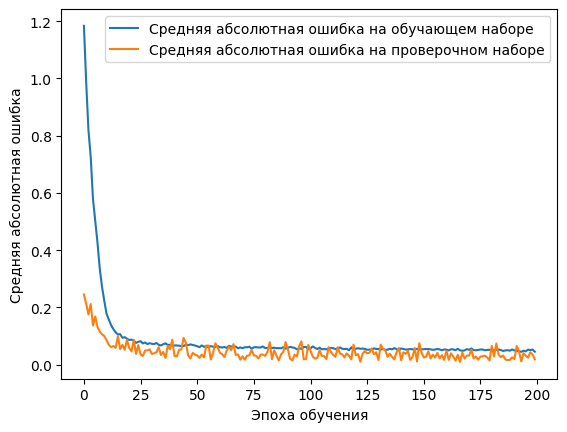

In [ ]:
plt.plot(history.history['mae'], label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history.history['val_mae'], label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка')
plt.legend()
plt.show()

In [ ]:
best_model = load_model('best_model.keras')

In [ ]:
y_pred = best_model.predict(X_test)
percent_errors = np.abs(y_test_scaled - y_pred.flatten()) / y_test_scaled * 100
mean_percent_error = np.mean(percent_errors)

print(f'Средний процент ошибки на проверочной выборке: {mean_percent_error:.1f}%')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Средний процент ошибки на проверочной выборке: 1.7%
